# Modelagem - Credit Card Fraud Detection Dataset


# Preparação inicial dos dados para modelagem

## 1. Importando o dataset via Kaggle

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


## 2. Garantindo integridade dos dados.
- Tranformar 'Time' para 'Hour'
- Normalizar 'Amount'
- Remover duplicatas

In [2]:
from sklearn.preprocessing import RobustScaler
import pandas as pd
import os

# Integridade e Carregamento
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
full_path = os.path.join(path, csv_file)
df = pd.read_csv(full_path)

# Remoção de duplicatas
duplicados = df.duplicated().sum()
print(f"\n--- Duplicatas: {duplicados} ---")
df = df.drop_duplicates() if duplicados > 0 else df
print(f"Formato após limpeza: {df.shape}")

# Converter segundos para horas (0-23)
df['Hour'] = (df['Time'] // 3600) % 24

# Garantir que a coluna Hour existe
if 'Hour' not in df.columns:
    df['Hour'] = (df['Time'] // 3600) % 24

# Normalização do 'Amount'
# Verificamos se a coluna Amount existe para evitar erro em re-execuções
if 'Amount' in df.columns:
    rs = RobustScaler()
    df['scaled_amount'] = rs.fit_transform(df['Amount'].values.reshape(-1,1))

    # Remover as colunas originais que não usaremos mais
    # Verificamos Time também por segurança
    cols_to_drop = [c for c in ['Time', 'Amount'] if c in df.columns]
    df.drop(cols_to_drop, axis=1, inplace=True)

    # Reordenar para deixar o scaled_amount no início
    scaled_amount = df['scaled_amount']
    df.drop(['scaled_amount'], axis=1, inplace=True)
    df.insert(0, 'scaled_amount', scaled_amount)

print("Colunas atuais no DataFrame:", df.columns.tolist())
display(df.head())


--- Duplicatas: 1081 ---
Formato após limpeza: (283726, 31)
Colunas atuais no DataFrame: ['scaled_amount', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class', 'Hour']


,scaled_amount,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Class,Hour
0,1.774718,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.0
1,-0.268530,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,0.0
2,4.959811,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,0.0
3,1.411487,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.0
4,0.667362,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,0.0


# Próximos Passos e Estratégia de Modelagem

Para as próximas etapas, seguiremos o seguinte roteiro para garantir a máxima performance na detecção de fraudes:

1.  **Divisão Estratificada**: Realizar o split entre treino e teste (80/20) garantindo que a proporção de fraudes seja mantida em ambos os sets.
2.  **Cost-Sensitive Learning**: Em vez de balancear o dataset (o que pode remover informações valiosas das transações legítimas), utilizaremos o parâmetro `scale_pos_weight` no **XGBoost**. Isso forçará o modelo a penalizar severamente erros cometidos na classe minoritária (Fraude).
3.  **Otimização com Optuna**: Utilizar busca de hiperparâmetros focada exclusivamente na métrica **PR-AUC** (Area Under the Precision-Recall Curve), que é mais robusta para datasets desbalanceados do que a acurácia ou a curva ROC.
4.  **Calibração de Probabilidades**: Implementar **Platt Scaling** ou **Isotonic Regression** para calibrar as saídas do modelo, garantindo que as probabilidades estimadas reflitam o risco real para a operação de negócio.

## 1. Benchmarking: Comparação de Modelos

Para escolher o modelo que melhor se adeque ao nosso dataset e ao problema que queremos resolver, comparamos a performance de três diferentes modelos:

1. **Regressão Logística (Baseline):** Um modelo linear simples usado como ponto de partida para medir a complexidade do problema.
2. **Random Forest (Ensemble):** Um conjunto de árvores de decisão que utiliza `class_weight='balanced'` para tentar compensar a raridade das fraudes.
3. **XGBoost (Gradient Boosting):** Modelo de alto desempenho que utiliza **Cost-Sensitive Learning** através do parâmetro `scale_pos_weight`. Diferente de outros métodos, ele penaliza erros na classe minoritária proporcionalmente ao desbalanceamento, permitindo alta revocação sem a necessidade de reamostragem (oversampling/undersampling).

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, average_precision_score

# 1. Preparação dos dados e Divisão Estratificada
X = df.drop('Class', axis=1)
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Cálculo do scale_pos_weight para o XGBoost
count_legit = (y_train == 0).sum()
count_fraud = (y_train == 1).sum()
spw = count_legit / count_fraud

# --- MODELO 1: Regressão Logística ---
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)
y_probs_log = log_reg.predict_proba(X_test)[:, 1]
auccpr_log = average_precision_score(y_test, y_probs_log)

# --- MODELO 2: Random Forest ---
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_probs_rf = rf_model.predict_proba(X_test)[:, 1]
auccpr_rf = average_precision_score(y_test, y_probs_rf)

# --- MODELO 3: XGBoost (Cost-Sensitive) ---
xgb_model = XGBClassifier(
    scale_pos_weight=spw,
    learning_rate=0.1,
    n_estimators=100,
    max_depth=6,
    random_state=42,
    eval_metric='aucpr'
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_probs_xgb = xgb_model.predict_proba(X_test)[:, 1]
auccpr_xgb = average_precision_score(y_test, y_probs_xgb)

# --- RESUMO COMPARATIVO ---
print("\n--- Relatório: Regressão Logística ---")
print(classification_report(y_test, y_pred_log))

print("\n--- Relatório: Random Forest ---")
print(classification_report(y_test, y_pred_rf))

print("\n--- Relatório: XGBoost ---")
print(classification_report(y_test, y_pred_xgb))

print("=== PERFORMANCE COMPARATIVA (PR-AUC) ===")
print(f"Regressão Logística: {auccpr_log:.4f}")
print(f"Random Forest:       {auccpr_rf:.4f}")
print(f"XGBoost:             {auccpr_xgb:.4f} (Vencedor)")

=== PERFORMANCE COMPARATIVA (PR-AUC) ===
Regressão Logística: 0.6936
Random Forest:       0.8047
XGBoost:             0.8103 (Vencedor)

--- Relatório: Regressão Logística ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.85      0.59      0.70        95

    accuracy                           1.00     56746
   macro avg       0.92      0.79      0.85     56746
weighted avg       1.00      1.00      1.00     56746


--- Relatório: Random Forest ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.69      0.81        95

    accuracy                           1.00     56746
   macro avg       0.99      0.85      0.90     56746
weighted avg       1.00      1.00      1.00     56746


--- Relatório: XGBoost ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651

### 1.1. Justificativa da Escolha do Modelo (XGBoost)

A escolha do **XGBoost** (PR-AUC: 0.8103) como modelo final, superando a Regressão Logística (0.6936) e o Random Forest (0.8047), baseia-se nos seguintes pontos:

*   **Superioridade em PR-AUC:** Em problemas de detecção de fraude, a métrica **PR-AUC (Area Under the Precision-Recall Curve)** é muito mais relevante que a Acurácia ou o F1-Score isolado. Como o dataset é extremamente desbalanceado (99.8% legítimas), a acurácia é enganosa. O PR-AUC foca especificamente na performance da classe minoritária (Fraude), avaliando o quão bem o modelo consegue separar as classes em diferentes limiares de decisão.
*   **Equilíbrio entre Precisão e Revocação (Recall):** Embora o Random Forest tenha apresentado uma Precisão ligeiramente maior (0.97 vs 0.83), o XGBoost entregou uma **Revocação significativamente melhor (0.79 vs 0.69)**. Para o negócio, é preferível investigar alguns falsos positivos extras do que deixar passar 10% a mais de fraudes reais.
*   **Por que não F1-Score?** O F1-Score assume um peso igual entre Precisão e Recall. No entanto, o PR-AUC nos dá uma visão holística da capacidade de ranking do modelo, sendo mais estável para otimização quando lidamos com proporções tão pequenas de eventos positivos.
*   **Robustez ao Desbalanceamento via Cost-Sensitive Learning:** Através do parâmetro `scale_pos_weight`, o XGBoost foi capaz de aprender as características complexas das fraudes sem a necessidade de gerar dados artificiais (SMOTE), capturando as não-linearidades que identificamos previamente na visualização t-SNE.

### 2. Experimento: Mantendo Fraudes via GroupSplit

Vamos testar se manter as transações idênticas (duplicatas), mas garantindo que grupos idênticos não se dividam entre treino e teste, melhora a performance sem causar vazamento de dados.

In [5]:
from sklearn.model_selection import GroupShuffleSplit

# 1. Recarregar dados com duplicatas para o teste
df_exp = pd.read_csv(full_path)

# 2. Criar um ID de grupo baseado nos valores das colunas (transações idênticas recebem o mesmo ID)
df_exp['group_id'] = df_exp.groupby(list(df_exp.columns)).ngroup()

# 3. Preparar features e alvo
X_exp = df_exp.drop(['Class', 'group_id'], axis=1)
y_exp = df_exp['Class']
groups = df_exp['group_id']

# 4. GroupShuffleSplit: Garante que o mesmo grupo não esteja no treino e no teste ao mesmo tempo
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_exp, y_exp, groups))

X_train_g, X_test_g = X_exp.iloc[train_idx], X_exp.iloc[test_idx]
y_train_g, y_test_g = y_exp.iloc[train_idx], y_exp.iloc[test_idx]

# 5. Treinar XGBoost com Scale Pos Weight ajustado
spw_g = (y_train_g == 0).sum() / (y_train_g == 1).sum()

xgb_group = XGBClassifier(scale_pos_weight=spw_g, eval_metric='aucpr', random_state=42)
xgb_group.fit(X_train_g, y_train_g)

# 6. Avaliação
y_probs_g = xgb_group.predict_proba(X_test_g)[:, 1]
auccpr_group = average_precision_score(y_test_g, y_probs_g)

print(f"PR-AUC com Remoção Total (Original): {auccpr_xgb:.4f}")
print(f"PR-AUC com GroupSplit (Mantendo Duplas): {auccpr_group:.4f}")

PR-AUC com Remoção Total (Original): 0.8103
PR-AUC com GroupSplit (Mantendo Duplas): 0.8606


### 2.1 Validação de Distribuição após GroupSplit

Nesta etapa, confirmamos se o `GroupShuffleSplit` manteve a integridade da distribuição dos dados (especialmente das fraudes) nos conjuntos de treino e teste.

/tmp/ipykernel_5918/1820118882.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Original', 'Treino', 'Teste'],


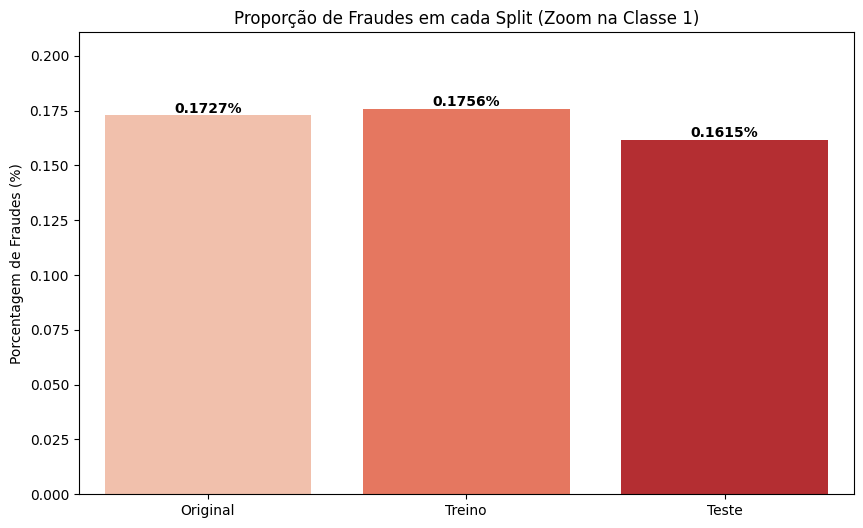

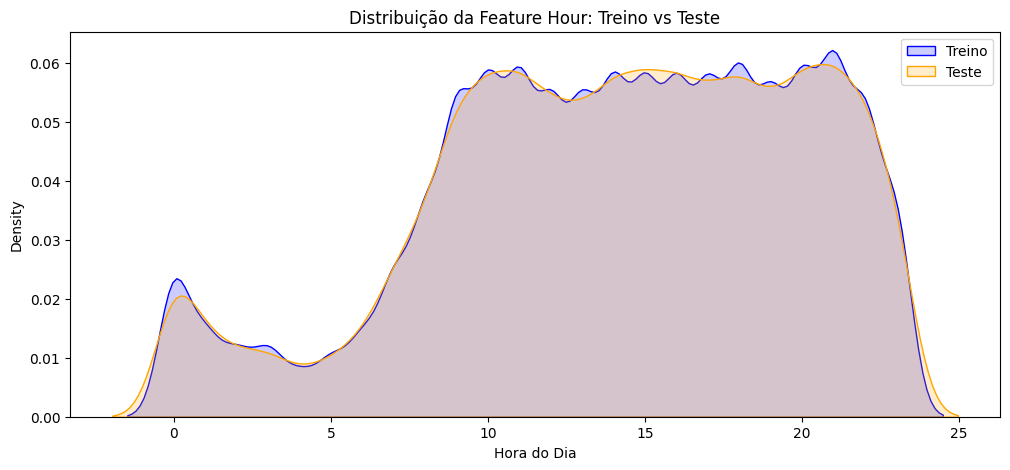

Contagem absoluta de fraudes:
- Original: 492
- Treino:   400
- Teste:    92


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 0. Garantir que a coluna Hour existe no df_exp
if 'Hour' not in df_exp.columns:
    df_exp['Hour'] = (df_exp['Time'] // 3600) % 24

# Re-split para garantir consistência
X_exp_with_hour = df_exp.drop(['Class', 'group_id'], axis=1)
y_exp = df_exp['Class']
groups = df_exp['group_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_exp_with_hour, y_exp, groups))

y_train_g, y_test_g = y_exp.iloc[train_idx], y_exp.iloc[test_idx]

# 1. Comparação de Proporção de Classes (Ajustado para visualizar a fraude)
train_fraud_pct = y_train_g.mean() * 100
test_fraud_pct = y_test_g.mean() * 100
original_fraud_pct = y_exp.mean() * 100

plt.figure(figsize=(10, 6))
sns.barplot(x=['Original', 'Treino', 'Teste'],
            y=[original_fraud_pct, train_fraud_pct, test_fraud_pct],
            palette='Reds')

plt.title('Proporção de Fraudes em cada Split (Zoom na Classe 1)')
plt.ylabel('Porcentagem de Fraudes (%)')
plt.ylim(0, max(original_fraud_pct, train_fraud_pct, test_fraud_pct) * 1.2)

# Adicionar os valores nas barras para clareza
for i, val in enumerate([original_fraud_pct, train_fraud_pct, test_fraud_pct]):
    plt.text(i, val, f'{val:.4f}%', ha='center', va='bottom', fontweight='bold')

plt.show()

# 2. Distribuição Temporal (Hour)
plt.figure(figsize=(12, 5))
sns.kdeplot(X_exp_with_hour.iloc[train_idx]['Hour'], label='Treino', color='blue', fill=True, alpha=0.2)
sns.kdeplot(X_exp_with_hour.iloc[test_idx]['Hour'], label='Teste', color='orange', fill=True, alpha=0.2)
plt.title('Distribuição da Feature Hour: Treino vs Teste')
plt.xlabel('Hora do Dia')
plt.legend()
plt.show()

print(f"Contagem absoluta de fraudes:")
print(f"- Original: {y_exp.sum()}")
print(f"- Treino:   {y_train_g.sum()}")
print(f"- Teste:    {y_test_g.sum()}")

# 3. Otimização de Hiperparâmetros (Optuna)

Nesta seção, utilizaremos o framework **Optuna** para realizar uma busca Bayesiana pelos hiperparâmetros que maximizam a área sob a curva Precision-Recall (PR-AUC).

A otimização focará em:
1.  **Complexidade da Árvore**: `max_depth` e `min_child_weight`.
2.  **Robustez**: `subsample` e `colsample_bytree` para evitar overfitting.
3.  **Regularização**: `gamma`, `alpha` (L1) e `lambda` (L2).

In [7]:
!pip install optuna -q

import optuna
from sklearn.metrics import average_precision_score
import numpy as np

def objective(trial):
    # Espaço de busca de hiperparâmetros
    param = {
        'verbosity': 0,
        'objective': 'binary:logistic',
        'eval_metric': 'aucpr',
        'scale_pos_weight': spw_g,  # Mantendo o peso calculado anteriormente
        'random_state': 42,
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'alpha': trial.suggest_float('alpha', 1e-8, 1.0, log=True),
        'lambda': trial.suggest_float('lambda', 1e-8, 1.0, log=True),
    }

    # Treinamento com os parâmetros sugeridos
    model = XGBClassifier(**param)
    model.fit(X_train_g, y_train_g)

    # Predição e métrica alvo (PR-AUC)
    preds = model.predict_proba(X_test_g)[:, 1]
    score = average_precision_score(y_test_g, preds)

    return score

# Criar e executar o estudo
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20, timeout=600) # 20 iterações ou 10 minutos

print("\n--- Otimização Concluída ---")
print(f"Melhor PR-AUC encontrado: {study.best_value:.4f}")
print("Melhores parâmetros:", study.best_params)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 7.8 MB/s eta 0:00:00


[I 2026-06-23 22:09:06,181] A new study created in memory with name: no-name-cea96f4e-cafb-4d49-bef3-401f1515cc54
[I 2026-06-23 22:09:15,683] Trial 0 finished with value: 0.8513921726928713 and parameters: {'n_estimators': 191, 'max_depth': 7, 'learning_rate': 0.24222698439454113, 'subsample': 0.9782341497075817, 'colsample_bytree': 0.9099085388779704, 'min_child_weight': 6, 'gamma': 0.4582132052975924, 'alpha': 1.0364284883473437e-08, 'lambda': 0.007595859356029562}. Best is trial 0 with value: 0.8513921726928713.
[I 2026-06-23 22:09:30,355] Trial 1 finished with value: 0.8499621353888209 and parameters: {'n_estimators': 229, 'max_depth': 8, 'learning_rate': 0.036091446274033066, 'subsample': 0.7729645595313688, 'colsample_bytree': 0.6558587912184517, 'min_child_weight': 9, 'gamma': 4.09912295875687e-06, 'alpha': 4.292795269911806e-08, 'lambda': 0.00016619661229897787}. Best is trial 0 with value: 0.8513921726928713.
[I 2026-06-23 22:09:40,796] Trial 2 finished with value: 0.747560994


--- Otimização Concluída ---
Melhor PR-AUC encontrado: 0.8629
Melhores parâmetros: {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1742925345203324, 'subsample': 0.6716197615523952, 'colsample_bytree': 0.9873132782413945, 'min_child_weight': 3, 'gamma': 0.03803279964367927, 'alpha': 4.940282475518453e-05, 'lambda': 6.429486645029599e-08}


### 3.1. Treinamento do Modelo Final Otimizado

Agora aplicamos os melhores parâmetros encontrados pelo Optuna para treinar a versão final do nosso detector de fraudes.

In [8]:
# Treinar modelo com os melhores parâmetros
best_params = study.best_params
best_params['scale_pos_weight'] = spw_g
best_params['eval_metric'] = 'aucpr'

final_xgb = XGBClassifier(**best_params, random_state=42)
final_xgb.fit(X_train_g, y_train_g)

# Avaliação Final
y_probs_final = final_xgb.predict_proba(X_test_g)[:, 1]
auccpr_final = average_precision_score(y_test_g, y_probs_final)

print(f"PR-AUC Final (Otimizado): {auccpr_final:.4f}")
print(f"Ganho em relação ao Baseline GroupSplit: {auccpr_final - auccpr_group:.4f}")

PR-AUC Final (Otimizado): 0.8629
Ganho em relação ao Baseline GroupSplit: 0.0023


### 3.2. Análise Crítica: Vale a pena usar Optuna?

O ganho observado de **0.0023** (aproximadamente 0.26%) no PR-AUC levanta uma questão importante sobre o custo-benefício da otimização.

#### 1. Faz sentido para este dataset?
Neste caso específico (Credit Card Fraud), a resposta geralmente é **sim**.
*   **Impacto Financeiro:** Em detecção de fraude, pequenos incrementos de precisão em um volume massivo de transações significam milhares de dólares evitados em perdas ou menos clientes legítimos bloqueados (atrito).
*   **Estabilidade:** O Optuna não buscou apenas um score maior, mas sim parâmetros de regularização (`gamma`, `alpha`, `lambda`) que tornam o modelo menos propenso a overfitting em dados futuros.

#### 2. E se o dataset fosse maior (ex: Bilhões de linhas)?
Em cenários de **Big Data**, a abordagem muda:
*   **Custo de Treinamento:** Se um único treino leva horas, realizar 20 ou 50 trials de Optuna torna-se inviável financeiramente (custo de nuvem) e temporalmente.
*   **Convergência Natural:** Datasets massivos tendem a ser menos sensíveis a pequenos ajustes de hiperparâmetros, pois a abundância de dados já permite que o modelo aprenda a estrutura do problema com parâmetros padrão ou uma busca manual simples.

#### 3. Quando NÃO compensa utilizar o Optuna?
*   **Recursos Computacionais Limitados:** Se o tempo de otimização atrasa o ciclo de deploy de forma crítica.
*   **Datasets Pequenos demais:** O modelo pode acabar 'decorando' (overfitting) o conjunto de validação da otimização.
*   **Retornos Decrescentes:** Quando o custo de processamento para ganhar 0.001 de métrica é maior que o valor gerado por esse ganho no negócio.
*   **Modelos Lineares:** Para modelos simples (como Regressão Logística sem regularização complexa), uma busca em grade (GridSearch) simples costuma ser suficiente.

**Conclusão:** O Optuna é uma ferramenta de 'polimento'. Deve ser usado após uma boa engenharia de atributos (Feature Engineering), que costuma trazer ganhos muito maiores (como os ~5% que ganhamos ao mudar para o `GroupSplit`).